# Inspect spatial split clustering

In [34]:
from pathlib import Path
import pandas as pd
import yaml
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()

DATASET = 'full_merged'

split_path = ROOT / 'splits' / f'spatial_split_{DATASET}.csv'
split = pd.read_csv(split_path)
train_ids = set(split.loc[split['spatial_split'] == 'spatial_train', 'id'])
holdout_ids = set(split.loc[split['spatial_split'] == 'spatial_holdout', 'id'])

cfg = yaml.safe_load((ROOT / 'configs' / 'data.yaml').read_text())
data_path = (ROOT / cfg['full_merged_path']).resolve()

coords = pq.read_table(data_path, columns=['id','x_25833','y_25833']).to_pandas()
coords = coords.drop_duplicates('id')

df = split.merge(coords, on='id', how='left')


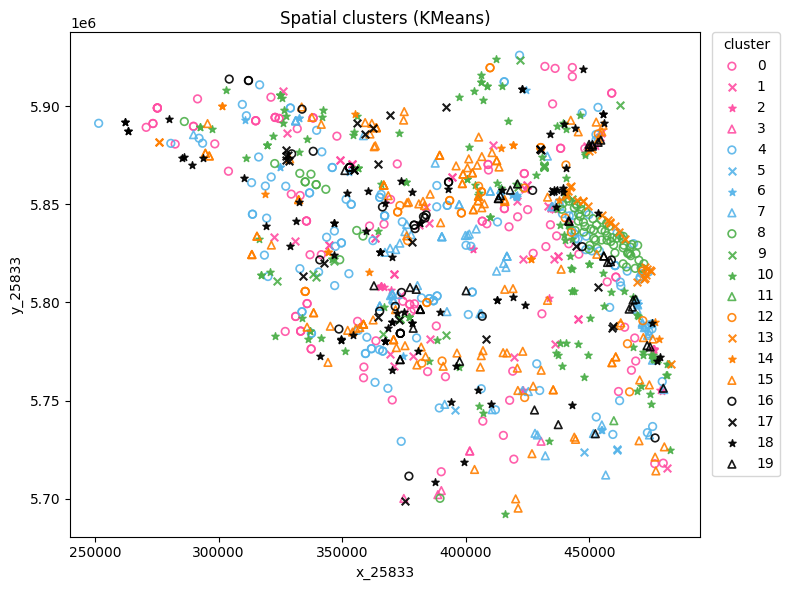

In [35]:
plt.figure(figsize=(8, 6))
clusters = sorted(df['cluster'].dropna().unique())
colors = ['#ff4fa3', '#56B4E9', '#4daf4a', '#ff7f00', '#000000']  # pink, light blue, green, orange, black
markers = ['o', 'x', '*', '^']

for i, c in enumerate(clusters):
    sub = df[df['cluster'] == c]
    color = colors[(i // len(markers)) % len(colors)]
    marker = markers[i % len(markers)]
    if marker in ['o', '^']:
        plt.scatter(
            sub['x_25833'],
            sub['y_25833'],
            s=30,
            alpha=0.9,
            facecolors='none',
            edgecolors=color,
            linewidths=1.2,
            marker=marker,
            label=str(c),
        )
    else:
        plt.scatter(
            sub['x_25833'],
            sub['y_25833'],
            s=30,
            alpha=0.9,
            color=color,
            marker=marker,
            label=str(c),
        )

plt.title('Spatial clusters (KMeans)')
plt.xlabel('x_25833')
plt.ylabel('y_25833')
plt.legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

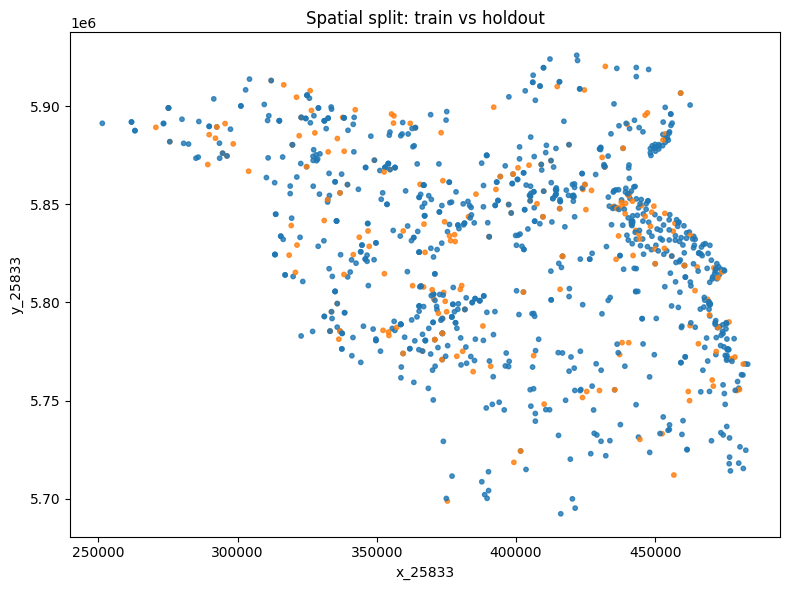

In [36]:

plt.figure(figsize=(8, 6))
colors = df['spatial_split'].map({'spatial_train': 'tab:blue', 'spatial_holdout': 'tab:orange'})
plt.scatter(df['x_25833'], df['y_25833'], c=colors, s=10, alpha=0.8)
plt.title('Spatial split: train vs holdout')
plt.xlabel('x_25833')
plt.ylabel('y_25833')
plt.tight_layout()
plt.show()

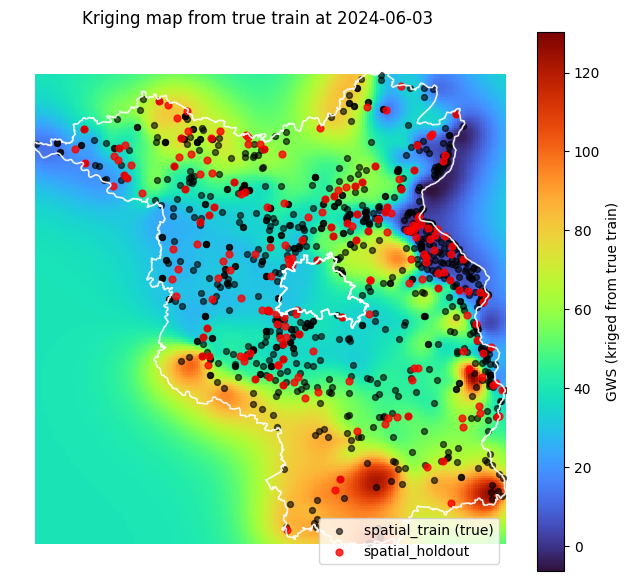

In [38]:
# Kriging map from true train values (colorful + legend)
import numpy as np
import json
from pyproj import Transformer
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler

gws = pq.read_table(data_path, columns=['datum','id','gws','x_25833','y_25833']).to_pandas()
gws['datum'] = pd.to_datetime(gws['datum'])
last_date = gws['datum'].max()
gws_last = gws[gws['datum'] == last_date][['id','gws']].merge(coords, on='id', how='left')

holdout_eval = gws_last[gws_last['id'].isin(holdout_ids)].dropna()
train_true_eval = gws_last[gws_last['id'].isin(train_ids)].dropna()

X_train_true = train_true_eval[['x_25833', 'y_25833']].values
y_train_true = train_true_eval['gws'].values
X_holdout = holdout_eval[['x_25833', 'y_25833']].values

scaler_true = StandardScaler()
X_train_true_s = scaler_true.fit_transform(X_train_true)
X_holdout_true_s = scaler_true.transform(X_holdout)

kernel_true = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1e-3)
gpr_true = GaussianProcessRegressor(kernel=kernel_true, normalize_y=True, n_restarts_optimizer=2)
gpr_true.fit(X_train_true_s, y_train_true)

GRID_NX = 200
GRID_NY = 200
xmin, xmax = coords['x_25833'].min(), coords['x_25833'].max()
ymin, ymax = coords['y_25833'].min(), coords['y_25833'].max()
xs = np.linspace(xmin, xmax, GRID_NX)
ys = np.linspace(ymin, ymax, GRID_NY)
xx, yy = np.meshgrid(xs, ys)
X_grid = np.column_stack([xx.ravel(), yy.ravel()])
X_grid_s_true = scaler_true.transform(X_grid)
z_true = gpr_true.predict(X_grid_s_true).reshape(xx.shape)

BOUNDARY_PATH = '../data/boundaries/geoBoundaries-DEU-ADM1_simplified.geojson'
BOUNDARY_NAMES = {'Berlin', 'Brandenburg'}

def _rings(path, names):
    data = json.load(open(path))
    feats = [f for f in data.get('features', []) if f.get('properties', {}).get('shapeName') in names]
    if not feats:
        return []
    tr = Transformer.from_crs('EPSG:4326', 'EPSG:25833', always_xy=True)
    rings = []
    for feat in feats:
        geom = feat.get('geometry', {})
        gtype = geom.get('type')
        coords = geom.get('coordinates', [])
        polys = [coords] if gtype == 'Polygon' else coords if gtype == 'MultiPolygon' else []
        for poly in polys:
            for ring in poly:
                xs, ys = zip(*[tr.transform(lon, lat) for lon, lat in ring])
                rings.append((list(xs), list(ys)))
    return rings

def plot_admin_boundaries(ax, rings, **kwargs):
    for xs, ys in rings:
        ax.plot(xs, ys, **kwargs)

boundary_rings = _rings(BOUNDARY_PATH, BOUNDARY_NAMES)

vmin_true = float(min(np.nanmin(z_true), np.nanmin(y_train_true), np.nanmin(holdout_eval['gws'])))
vmax_true = float(max(np.nanmax(z_true), np.nanmax(y_train_true), np.nanmax(holdout_eval['gws'])))
norm_true = plt.Normalize(vmin=vmin_true, vmax=vmax_true)

fig_true, ax_true = plt.subplots(figsize=(8, 7))
cf_true = ax_true.pcolormesh(xx, yy, z_true, shading='auto', cmap='turbo', norm=norm_true)
plt.colorbar(cf_true, ax=ax_true, label='GWS (kriged from true train)')

plot_admin_boundaries(ax_true, boundary_rings, color='white', linewidth=1.2, alpha=0.9)

ax_true.scatter(train_true_eval['x_25833'], train_true_eval['y_25833'], s=18, c='black', label='spatial_train (true)', alpha=0.6)
ax_true.scatter(holdout_eval['x_25833'], holdout_eval['y_25833'], s=24, c='red', label='spatial_holdout', alpha=0.8)

for spine in ax_true.spines.values():
    spine.set_visible(False)
ax_true.set_xticks([])
ax_true.set_yticks([])
ax_true.set_title(f'Kriging map from true train at {last_date.date()}')
ax_true.legend(loc='lower right')


In [ ]:
train_ids = set(split.loc[split['spatial_split'] == 'spatial_train', 'id'])
holdout_ids = set(split.loc[split['spatial_split'] == 'spatial_holdout', 'id'])
